In [55]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [ ]:
import zipfile

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Dataset extracted successfully!")

In [ ]:
import os
os.listdir('dataset')

In [ ]:
os.listdir('dataset/brain_tumor_dataset')

In [ ]:
train_dir = "dataset/brain_tumor_dataset"

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

In [53]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [8]:
train_data.class_indices

{'no': 0, 'yes': 1}

In [9]:
images, labels = next(train_data)

print(images.shape)   # (32, 224, 224, 3)
print(labels.shape)   # (32,)

(32, 224, 224, 3)
(32,)


UI and Model

In [10]:
!pip install -q streamlit tensorflow pillow matplotlib pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 89.1 MB/s eta 0:00:00


In [47]:
%%writefile model.py
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# Load YOUR trained model
model = tf.keras.models.load_model("tumor_model.keras")

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img)/255.0
    x = np.expand_dims(x, axis=0)

    pred = model.predict(x)[0][0]
    print("Raw prediction:", pred)

    if pred > 0.7:
        label= "Tumor Detected"
        confidence= float(pred)
    else:
        label= "No Tumor Detected"
        confidence= float(1 - pred)
    return label, confidence

Overwriting model.py


In [12]:
%%writefile app.py
import streamlit as st
from PIL import Image
import matplotlib.pyplot as plt
from model import predict_image

# Page config
st.set_page_config(page_title="Brain Tumor Detection", layout="wide")

# Title & description
st.title("🧠 Brain Tumor Detection System")
st.write("Upload a brain MRI image to detect possible tumor presence using AI")

# Sidebar (optional - can remove if not needed)
st.sidebar.header("Model Info")
st.sidebar.write("This AI model classifies MRI images into:")
st.sidebar.write("• Tumor Absent")
st.sidebar.write("• Tumor Present")

# Upload image
uploaded_file = st.file_uploader("Upload MRI Image", type=["jpg", "png", "jpeg"])

if uploaded_file:
    # Display image
    img = Image.open(uploaded_file)
    st.image(img, caption="Uploaded MRI Image", use_container_width=True)

    # Save temporarily
    with open("temp.jpg", "wb") as f:
        f.write(uploaded_file.getbuffer())

    # Prediction
    with st.spinner("🔍 Analyzing MRI scan..."):
        label, confidence = predict_image("temp.jpg")

    # Results
    st.subheader("🧾 AI Diagnosis Report")

    st.success(f"🧠 Diagnosis: {label}")

    # Medical-style interpretation
    if label == "No Tumor":
        st.info("✅ No tumor detected. Brain appears normal.")
    else:
        st.warning(f"⚠️ Possible {label} detected. Please consult a medical professional.")

    # Confidence score
    st.metric("Confidence", f"{confidence*100:.2f}%")

    # Safe progress bar
    st.progress(min(max(float(confidence), 0.0), 1.0))

Writing app.py


In [13]:
from pyngrok import ngrok

In [14]:

# Add your token here
ngrok.set_auth_token("3ClETFicapHcd8EIgq1fVDzqVjy_7hRW4WdmVpLLWvF2NL2Dj")

Loading the Resnet(Transfer Learning)

In [15]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
#Adding Custom Layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')   # Binary classification
])

In [43]:
base_model.trainable = False

for layer in base_model.layers[:-10]:
    layer.trainable = False

In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

In [46]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 66s 8s/step - accuracy: 0.6305 - loss: 0.7562 - val_accuracy: 0.6000 - val_loss: 0.6407
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 8s/step - accuracy: 0.5764 - loss: 0.6796 - val_accuracy: 0.5400 - val_loss: 0.6940
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 53s 8s/step - accuracy: 0.5714 - loss: 0.6681 - val_accuracy: 0.6400 - val_loss: 0.6666
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 7s/step - accuracy: 0.5369 - loss: 0.7005 - val_accuracy: 0.6600 - val_loss: 0.6145
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 7s/step - accuracy: 0.6108 - loss: 0.6791 - val_accuracy: 0.7000 - val_loss: 0.6124
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 81s 6s/step - accuracy: 0.6601 - loss: 0.6561 - val_accuracy: 0.6600 - val_loss: 0.6442
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - accuracy: 0.6059 - loss: 0.6364 - val_accuracy: 0.6600 - val_loss: 0.6413
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 8s/step - accuracy: 0.6158 - loss: 0.6349 - val_accuracy: 0.6000 - val_loss: 0.6420
Epoch 9/

In [51]:
#pred = model.predict(img)
#print("Prediction value:", pred)

In [31]:
model.save("tumor_model.keras")

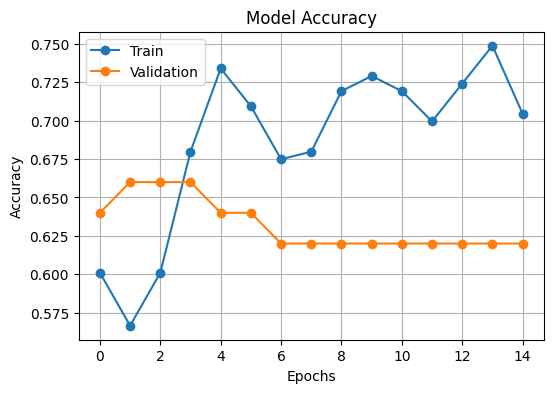

In [36]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.show()

In [23]:
model.fit(train_data, validation_data=val_data, epochs=3)

Epoch 1/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.7143 - loss: 0.5457 - val_accuracy: 0.6200 - val_loss: 0.6569
Epoch 2/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 8s/step - accuracy: 0.7833 - loss: 0.5168 - val_accuracy: 0.6200 - val_loss: 0.6630
Epoch 3/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 7s/step - accuracy: 0.7488 - loss: 0.4915 - val_accuracy: 0.6200 - val_loss: 0.6965


In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

UI Link

In [60]:
get_ipython().system_raw('streamlit run app.py &')

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://tapered-diabetes-breeding.ngrok-free.dev" -> "http://localhost:8501"


Accuracy

In [56]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [58]:
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['val_accuracy'])

Training Accuracy: [0.6305418610572815, 0.5763546824455261, 0.5714285969734192, 0.5369458198547363, 0.610837459564209, 0.6600984930992126, 0.6059113144874573, 0.6157635450363159, 0.6798029541969299, 0.6305418610572815, 0.6995074152946472, 0.6502463221549988, 0.6354680061340332, 0.6699507236480713, 0.6699507236480713]
Validation Accuracy: [0.6000000238418579, 0.5400000214576721, 0.6399999856948853, 0.6600000262260437, 0.699999988079071, 0.6600000262260437, 0.6600000262260437, 0.6000000238418579, 0.7200000286102295, 0.6200000047683716, 0.6800000071525574, 0.7400000095367432, 0.6600000262260437, 0.800000011920929, 0.699999988079071]


In [59]:
model.evaluate(val_data)

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.7600 - loss: 0.5515


[0.5514901876449585, 0.7599999904632568]